In [1]:
try:
    %pip install --user "oracledb" --no-warn-script-location
except Exception as e:
    print("Install error")
    raise

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import oracledb

Note: you may need to restart the kernel to use updated packages.


In [2]:
weekly_df = pd.read_csv("all-weeks-global.csv", encoding="latin1")

weekly_df = weekly_df[
    [
        "week",
        "category",
        "weekly_rank",
        "show_title",
        "season_title",
        "weekly_hours_viewed",
        "weekly_views"
    ]
].copy()

weekly_df = weekly_df.dropna(subset=["show_title"])

def normalize_title(text):
    if pd.isna(text):
        return None
    text = str(text).lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

weekly_df["show_title"] = weekly_df["show_title"].apply(normalize_title)
weekly_df["category"] = weekly_df["category"].astype(str).str.lower().str.strip()

weekly_df["week"] = pd.to_datetime(weekly_df["week"], errors="coerce")
weekly_df = weekly_df.dropna(subset=["week"])

weekly_df["weekly_rank"] = pd.to_numeric(weekly_df["weekly_rank"], errors="coerce")
weekly_df["weekly_hours_viewed"] = pd.to_numeric(weekly_df["weekly_hours_viewed"], errors="coerce")
weekly_df["weekly_views"] = pd.to_numeric(weekly_df["weekly_views"], errors="coerce")

weekly_df = weekly_df.drop_duplicates()

weekly_df.to_csv("cleaned_weekly_global_q3.csv", index=False)

print("weekly rows:", weekly_df.shape)
weekly_df.head()

weekly rows: (5160, 7)


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,weekly_views
0,2023-12-17,films (english),1,leave the world behind,NaN,106200000,44900000.0
1,2023-12-17,films (english),2,chicken run dawn of the nugget,NaN,20300000,11900000.0
2,2023-12-17,films (english),3,leo,NaN,16800000,9400000.0
3,2023-12-17,films (english),4,family switch,NaN,16600000,9400000.0
4,2023-12-17,films (english),5,the super mario bros movie,NaN,13700000,8900000.0


In [3]:
popular_df = pd.read_csv("most-popular.csv", encoding="latin1")

popular_df = popular_df[
    [
        "category",
        "show_title",
        "season_title",
        "hours_viewed_first_91_days",
        "views_first_91_days"
    ]
].copy()

popular_df = popular_df.dropna(subset=["show_title"])

popular_df["show_title"] = popular_df["show_title"].apply(normalize_title)
popular_df["category"] = popular_df["category"].astype(str).str.lower().str.strip()

popular_df["hours_viewed_first_91_days"] = pd.to_numeric(
    popular_df["hours_viewed_first_91_days"], errors="coerce"
)
popular_df["views_first_91_days"] = pd.to_numeric(
    popular_df["views_first_91_days"], errors="coerce"
)

popular_df = popular_df.drop_duplicates()

popular_df.to_csv("cleaned_most_popular_q3.csv", index=False)

print("popular rows:", popular_df.shape)
popular_df.head()

popular rows: (40, 5)


,category,show_title,season_title,hours_viewed_first_91_days,views_first_91_days
0,films (english),red notice,NaN,454200000,230900000
1,films (english),dont look up,NaN,408600000,171400000
2,films (english),the adam project,NaN,281000000,157600000
3,films (english),bird box,NaN,325300000,157400000
4,films (english),the gray man,NaN,299500000,139300000


In [4]:
import oracledb

dsn = oracledb.makedsn("127.0.0.1", 1522, service_name="stu")

connection = oracledb.connect(
    user="ora_rish05",
    password="a71497275",
    dsn=dsn
)

print("Connected to Oracle")

Connected to Oracle


In [5]:
print(weekly_df.columns)
print(weekly_df.shape)
weekly_df.head()

Index(['week', 'category', 'weekly_rank', 'show_title', 'season_title',
       'weekly_hours_viewed', 'weekly_views'],
      dtype='object')
(5160, 7)


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,weekly_views
0,2023-12-17,films (english),1,leave the world behind,NaN,106200000,44900000.0
1,2023-12-17,films (english),2,chicken run dawn of the nugget,NaN,20300000,11900000.0
2,2023-12-17,films (english),3,leo,NaN,16800000,9400000.0
3,2023-12-17,films (english),4,family switch,NaN,16600000,9400000.0
4,2023-12-17,films (english),5,the super mario bros movie,NaN,13700000,8900000.0


In [6]:
cursor = connection.cursor()

try:
    cursor.execute("DROP TABLE weekly_global")
    print("Dropped weekly_global")
except Exception:
    print("weekly_global did not exist")

connection.commit()
cursor.close()

Dropped weekly_global


In [7]:
cursor = connection.cursor()

create_weekly_sql = """
CREATE TABLE weekly_global (
    week DATE,
    category VARCHAR2(100),
    weekly_rank NUMBER,
    show_title VARCHAR2(300),
    season_title VARCHAR2(300),
    weekly_hours_viewed NUMBER,
    weekly_views NUMBER
)
"""

cursor.execute(create_weekly_sql)
connection.commit()
print("weekly_global table created")

cursor.close()

weekly_global table created


In [8]:
cursor = connection.cursor()

cursor.execute("SELECT table_name FROM user_tables WHERE table_name = 'WEEKLY_GLOBAL'")
print(cursor.fetchall())

cursor.close()

[('WEEKLY_GLOBAL',)]


In [9]:
weekly_insert_df = weekly_df.copy()
weekly_insert_df["week"] = weekly_insert_df["week"].dt.strftime("%Y-%m-%d")
weekly_insert_df = weekly_insert_df.replace({np.nan: None})

print("Rows to insert:", len(weekly_insert_df))
weekly_insert_df.head()

Rows to insert: 5160


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,weekly_views
0,2023-12-17,films (english),1,leave the world behind,None,106200000,44900000.0
1,2023-12-17,films (english),2,chicken run dawn of the nugget,None,20300000,11900000.0
2,2023-12-17,films (english),3,leo,None,16800000,9400000.0
3,2023-12-17,films (english),4,family switch,None,16600000,9400000.0
4,2023-12-17,films (english),5,the super mario bros movie,None,13700000,8900000.0


In [10]:
cursor = connection.cursor()

weekly_sql = """
INSERT INTO weekly_global (
    week,
    category,
    weekly_rank,
    show_title,
    season_title,
    weekly_hours_viewed,
    weekly_views
)
VALUES (
    TO_DATE(:1, 'YYYY-MM-DD'),
    :2,
    :3,
    :4,
    :5,
    :6,
    :7
)
"""

weekly_data = list(weekly_insert_df.itertuples(index=False, name=None))
cursor.executemany(weekly_sql, weekly_data)

connection.commit()
print("Weekly rows inserted:", len(weekly_data))

cursor.close()

Weekly rows inserted: 5160


In [11]:
cursor = connection.cursor()

cursor.execute("SELECT COUNT(*) FROM weekly_global")
print("Row count in weekly_global:", cursor.fetchone()[0])

cursor.close()

Row count in weekly_global: 5160


In [12]:
cursor = connection.cursor()

cursor.execute("SELECT COUNT(*) FROM weekly_global")
print("Row count in weekly_global:", cursor.fetchone()[0])

cursor.close()

Row count in weekly_global: 5160


In [25]:
query = """
WITH ranked AS (
    SELECT
        category,
        show_title,
        week,
        NVL(weekly_views, 0) AS weekly_views,
        NVL(weekly_hours_viewed, 0) AS weekly_hours_viewed,
        weekly_rank,
        ROW_NUMBER() OVER (
            PARTITION BY category, show_title
            ORDER BY week
        ) AS rn
    FROM weekly_global
),
early AS (
    SELECT
        category,
        show_title,
        SUM(weekly_views) AS views_first3weeks,
        SUM(weekly_hours_viewed) AS hours_first3weeks,
        MIN(weekly_rank) AS best_rank
    FROM ranked
    WHERE rn <= 3
    GROUP BY category, show_title
),
later AS (
    SELECT
        category,
        show_title,
        SUM(weekly_views) AS views_weeks4to13
    FROM ranked
    WHERE rn BETWEEN 4 AND 13
    GROUP BY category, show_title
)
SELECT
    e.category,
    e.show_title,
    e.views_first3weeks,
    e.hours_first3weeks,
    e.best_rank,
    l.views_weeks4to13
FROM early e
JOIN later l
    ON e.category = l.category
   AND e.show_title = l.show_title
ORDER BY e.views_first3weeks DESC
"""

analysis_df = pd.read_sql(query, connection)
analysis_df.head()

/tmp/ipykernel_243/3888705911.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  analysis_df = pd.read_sql(query, connection)


,CATEGORY,SHOW_TITLE,VIEWS_FIRST3WEEKS,HOURS_FIRST3WEEKS,BEST_RANK,VIEWS_WEEKS4TO13
0,films (english),extraction 2,102500000,211900000,1,20800000
1,films (english),heart of stone,81900000,172100000,1,10000000
2,films (english),leo,72400000,129200000,1,9400000
3,films (non-english),nowhere,66900000,121500000,1,13500000
4,films (english),the outlaws,60300000,97500000,1,5500000


In [26]:
print("Rows in analysis_df:", len(analysis_df))

Rows in analysis_df: 393


In [27]:
analysis_df.to_csv("q3_result_table.csv", index=False)
print("Saved q3_result_table.csv")

Saved q3_result_table.csv


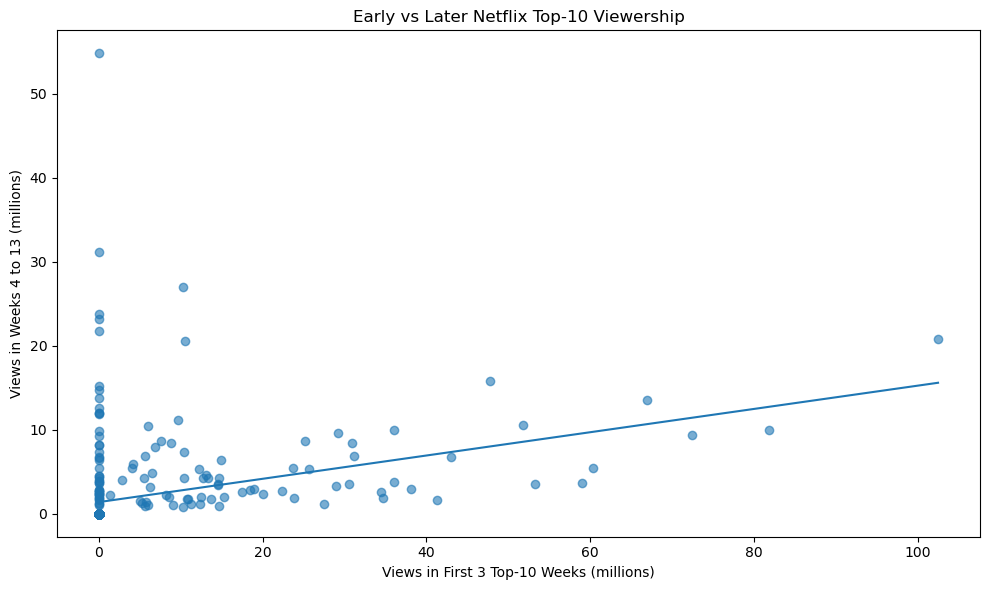

In [30]:
plot_df = analysis_df[["VIEWS_FIRST3WEEKS", "VIEWS_WEEKS4TO13"]].copy()

plot_df["VIEWS_FIRST3WEEKS"] = pd.to_numeric(plot_df["VIEWS_FIRST3WEEKS"], errors="coerce")
plot_df["VIEWS_WEEKS4TO13"] = pd.to_numeric(plot_df["VIEWS_WEEKS4TO13"], errors="coerce")

plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

plot_df["VIEWS_FIRST3WEEKS_M"] = plot_df["VIEWS_FIRST3WEEKS"] / 1_000_000
plot_df["VIEWS_WEEKS4TO13_M"] = plot_df["VIEWS_WEEKS4TO13"] / 1_000_000

x = plot_df["VIEWS_FIRST3WEEKS_M"].to_numpy()
y = plot_df["VIEWS_WEEKS4TO13_M"].to_numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b)

plt.xlabel("Views in First 3 Top-10 Weeks (millions)")
plt.ylabel("Views in Weeks 4 to 13 (millions)")
plt.title("Early vs Later Netflix Top-10 Viewership")

plt.tight_layout()
plt.savefig("q3_result_scatter_millions.png")
plt.show()

In [31]:
corr = analysis_df["VIEWS_FIRST3WEEKS"].corr(analysis_df["VIEWS_WEEKS4TO13"])
print("Correlation:", corr)

Correlation: 0.33890603121138607
